In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [76]:
df = pd.read_csv("../Data/telco_churn.csv")

In [77]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
df.shape

(7043, 21)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [80]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [81]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

1.Imported required libraries.
2.Loaded the data set using pd.read_csv().
3.pd.head() to verify whether the data is loading or not.
4.pd.shape(),pd.info() to observe the data ,how many rows, columns, datatypes, nullvalues.
5.df.columns,df['Churn'].value_counts() to check column names and try to figure our target column.
Each row of data has each costumers data.
'Churn' is target column. Shows whether costumer is still using company service or left the service.
Churn means the rate at which customers stop doing business with a company

In [82]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [83]:
df['Churn'].value_counts(normalize = True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

73.XX% of users are still using the company services.
And only 26.XX% of user left the company services.

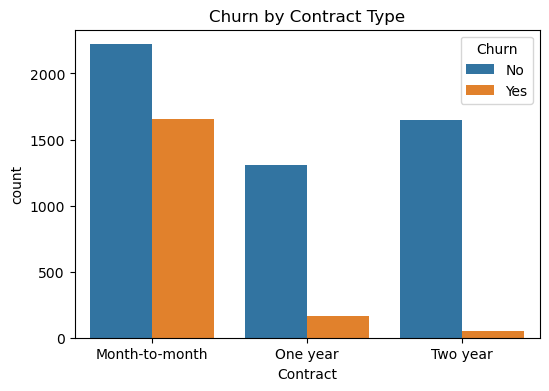

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

Customers in month to month contract type leaves more than yearly contract types
Also There are more customers in month to month contract type who are using company services more than remaning contracts

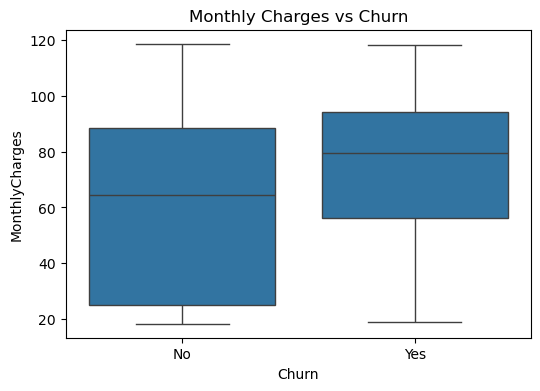

In [85]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn',y='MonthlyCharges', data= df) 
plt.title('Monthly Charges vs Churn')
plt.show()

Low paying customers churned less than high paying customers.
Customers who left usually paid more per month.
Customers with higher monthly charges are more likely to churn, possibly due to perceived high cost.

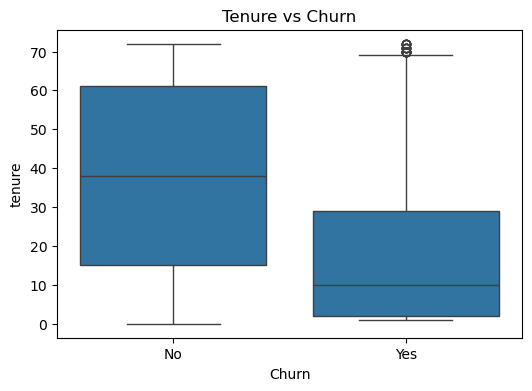

In [86]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

Customers with higher monthly charges are more likely to churn, possibly due to perceived high cost.

In [87]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No missing values were found in the dataset during inital inspection.

In [88]:
df['TotalCharges'].dtype

dtype('O')

In [89]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

errors='coerce' means If there are any hidden blank spaces or invalid values,
they will automatically become NaN.

In [90]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [91]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [92]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values in TotalCharges were caused by new customers with zero tenure and were safely handled by replacing them with 0.

In [93]:
df.drop('customerID',axis=1,inplace=True)

customerID was dropped as it is a unique identifier and does not contribute to churn prediction.

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Data cleaning completed. The dataset is now clean, consistent, and ready for preprocessing and machine learning.

In [95]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [96]:
x.shape

(7043, 19)

In [97]:
y.shape

(7043,)

In [98]:
x.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [99]:
cat_cols = x.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [100]:
num_cols = x.select_dtypes(exclude='object').columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [101]:
x_encoded = pd.get_dummies(x,columns=cat_cols, drop_first=True)

In [102]:
x_encoded.shape

(7043, 30)

Categorical variables were encoded using one-hot encoding to convert them into a numerical format suitable for machine learning models.

In [144]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train = x_train

import joblib

model = joblib.load("../churn_model_pipeline.pkl")
scaler = model.named_steps["scaler"]
lr_model = model.named_steps["model"]
X_train_scaled = scaler.transform(X_train)

import shap

explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)
joblib.dump(explainer, "../shap_explainer.pkl")

['../shap_explainer.pkl']

In [104]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

The dataset was split into training and testing sets using an 80–20 ratio with stratification to preserve the churn class distribution.

One-Hot Encoding

One-hot encoding is a technique used to convert categorical variables into numerical form by creating binary columns for each category without introducing any ordinal relationship.

Stratification

Stratification ensures that the class distribution of the target variable is preserved in both training and testing datasets during data splitting.

In [105]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)

C:\Users\marad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

ConvergenceWarning: lbfgs failed to converge
This means:
Logistic Regression is trying to find the best coefficients
Your features have very different scales
e.g. tenure (0–72)
MonthlyCharges (20–120)
TotalCharges (0–8000+)
Because of this, the optimizer struggles to converge
This is expected when data is NOT scaled
Is this an error?
No
The model still trained
But results may not be optimal

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled  = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [107]:
log_model_scaled = LogisticRegression(max_iter=1000)
log_model_scaled.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [108]:
y_pred_scaled = log_model_scaled.predict(x_test_scaled)

from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

[[925 110]
 [162 212]]
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Feature scaling was applied using StandardScaler to ensure faster convergence and improved performance of Logistic Regression. The model was retrained on scaled data to obtain stable and reliable results.

Your Confusion Matrix
[[925 110]
 [162 212]]
Interpretation:
	Predicted No	Predicted Yes
Actual No	925 (TN)	110 (FP)
Actual Yes	162 (FN)	212 (TP)
Key Metrics
Accuracy = 0.81 (81%)
Good overall.
Recall for Churn (Yes) = 0.57 (57%)
This is the important one.
Meaning:
Out of 374 actual churn customers, the model correctly identified 212.
But it missed 162 churn customers 
That’s:
162/374 ≈ 43% hurn customers missed
162/374≈43% churn customers missed
Interpretation (Very Important)
What this means:
Model is good at predicting Non-Churn (No)
But weaker at detecting Churn (Yes)
Recall = 57% → moderate but not strong
Professional Evaluation
For churn prediction:
Metric	      Value	Verdict
Accuracy	   81%	Good
Recall(Yes)	   57%	Moderate
Precision(Yes) 66%	Decent
F1-score	   0.61	Balanced but improvable
Business Perspective
Imagine:
374 customers are about to churn
Model detects only 212
162 leave without warning
Company still loses many customers.
What This Tells Us
Logistic Regression is:
Stable
Reasonable baseline
Not strong enough for churn detection

In [109]:
log_model_bal = LogisticRegression(max_iter=1000,class_weight='balanced')
log_model_bal.fit(x_train_scaled,y_train)  

LogisticRegression(class_weight='balanced', max_iter=1000)

In [110]:
y_pred_bal = log_model_bal.predict(x_test_scaled)

In [111]:
from sklearn.metrics import classification_report,confusion_matrix

print(confusion_matrix(y_test,y_pred_bal))
print(classification_report(y_test, y_pred_bal))

[[749 286]
 [ 80 294]]
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



To address class imbalance, Logistic Regression was trained using class-weight balancing. This significantly improved recall for churn customers from 57% to 79%, reducing the number of missed churn cases, albeit with a slight reduction in overall accuracy. Given the business importance of churn detection, the balanced model provides a better trade-off.
->Class imbalance is critical in churn problems
->Accuracy alone is misleading
->Recall can be improved intentionally
->ML is about trade-offs, not perfection

In [112]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state = 42,
    max_depth = 5 #controls overfitting
)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [113]:
y_pred_dt = dt_model.predict(x_test)

In [114]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[917 118]
 [172 202]]
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



This tree:
Is slightly worse than Logistic in recall
Missed 172 churn customers
Accuracy is decent
Not strong for churn detection
Because:
max_depth=5 limits complexity
Tree is simple and interpretable
But not powerful enough
Important Learning
Decision Trees:
Can capture non-linearity
But shallow trees underfit
Deep trees overfit
That’s why industry prefers:
Random Forest
It:
Combines many trees
Reduces overfitting
Usually improves recall significantly

In [115]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [116]:
y_pred_rf = rf_model.predict(x_test)

In [117]:
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

[[926 109]
 [183 191]]
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Balanced Logistic Regression is your best churn detector
Even though:
Accuracy dropped
Precision dropped
It reduced missed churn from:
162 → 80
That’s huge.

Why Random Forest Underperformed?
Because:
Dataset imbalance still exists
Default RF optimizes overall accuracy
It favors majority class (No)
We didn’t balance it yet.
we try to improve it by Balanced Randomforest

In [118]:
rf_model_bal = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model_bal.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [119]:
y_pred_rf_bal = rf_model_bal.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf_bal))
print(classification_report(y_test,y_pred_rf_bal))

[[923 112]
 [187 187]]
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Why Did Random Forest Fail?
Very important concept:
Your dataset is not extremely nonlinear
Features may be mostly linearly separable
Logistic Regression works very well on structured tabular data
RF default parameters may need tuning
This is normal.
Tree models are not always better.

Model Performance Comparison
Model	Accuracy	Recall (Churn)
Logistic Regression	81%	57%
Logistic (Balanced)	74%	79%
Decision Tree	    79%	54%
Random Forest	    79%	51%

Balanced Logistic Regression was selected as the final model due to its significantly higher recall in detecting churn customers.

In [120]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': log_model_bal.coef_[0]
})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
feature_importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.808897
3,TotalCharges,0.494748
23,StreamingMovies_Yes,0.285948
21,StreamingTV_Yes,0.273209
9,MultipleLines_Yes,0.201165
28,PaymentMethod_Electronic check,0.188783
26,PaperlessBilling_Yes,0.164703
17,DeviceProtection_Yes,0.058287
0,SeniorCitizen,0.056636
7,PhoneService_Yes,0.024336


Positive coefficient → Increases churn probability
Negative coefficient → Decreases churn probability
Larger magnitude → Stronger impact

In [121]:
feature_importance.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.099096
16,DeviceProtection_No internet service,-0.099096
14,OnlineBackup_No internet service,-0.099096
20,StreamingTV_No internet service,-0.099096
6,Dependents_Yes,-0.104292
13,OnlineSecurity_Yes,-0.114503
24,Contract_One year,-0.296706
25,Contract_Two year,-0.617746
2,MonthlyCharges,-1.039440
1,tenure,-1.159048


Feature Importance Analysis:
The feature importance analysis of the balanced Logistic Regression model revealed that tenure is the strongest negative predictor of churn, indicating that long-term customers are significantly less likely to leave. Additionally, customers with long-term contracts (one-year and two-year) show reduced churn probability.
On the other hand, fiber optic internet service and higher total charges were strong positive predictors of churn. Customers using electronic check payment methods and streaming services also showed higher churn tendencies.
These findings provide actionable business insights for targeted retention strategies.

Final Project Conclusion
Customer Churn Prediction Using Machine Learning
Technical Conclusion

In this project, a complete machine learning pipeline was implemented to predict customer churn in a telecom dataset. The workflow included:
Data cleaning and preprocessing
Handling missing values and correcting data types
Encoding categorical variables using one-hot encoding
Performing train–test split with stratification
Applying feature scaling where required
Training multiple classification models
Handling class imbalance using class weighting
Comparing model performance using recall-focused evaluation

Four models were evaluated:

Logistic Regression
Balanced Logistic Regression
Decision Tree
Random Forest

Among these, Balanced Logistic Regression demonstrated the best performance for churn detection, achieving a recall of 79% for churn customers. This significantly reduced the number of missed churn cases compared to other models.

Although overall accuracy slightly decreased, the improvement in recall makes the balanced model more suitable for churn prediction, where identifying potential churners is more critical than overall accuracy.

Business Conclusion

The feature importance analysis revealed key churn-driving factors:
High Churn Risk Factors:
Fiber optic internet service
Higher total charges
Electronic check payment method
Streaming services usage
Month-to-month contracts
Low Churn Risk Factors:
Longer customer tenure (strongest churn reducer)
One-year and two-year contracts
Customers with dependents
Security-related service subscriptions
These insights suggest that retention strategies should focus on:
Monitoring new and short-tenure customers
Offering incentives for long-term contracts
Targeting fiber optic users with service quality improvements
Encouraging automatic or secure payment methods

Key Learning Outcomes

This project demonstrated:
The importance of handling class imbalance in churn problems
Why accuracy alone is not a sufficient evaluation metric
The trade-off between precision and recall
The practical value of feature importance for business decisions
That simpler linear models can outperform complex ensemble models in structured tabular datasets

Future Improvements
Future enhancements could include:
Hyperparameter tuning using GridSearchCV
SMOTE for synthetic minority oversampling
ROC-AUC curve comparison
Threshold tuning to further optimize recall
Deployment using Streamlit or Flask
Real-time churn prediction system

Final Statement
The Balanced Logistic Regression model was selected as the final churn prediction model due to its superior ability to identify potential churn customers. The project successfully combines machine learning techniques with actionable business insights, making it both technically sound and practically valuable.

In [122]:
y_prob_lr = log_model_bal.predict_proba(x_test_scaled)[:,1]

In [123]:
from sklearn.metrics import roc_auc_score
auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Balanced Logistic Regression AUC:", auc_lr)

Balanced Logistic Regression AUC: 0.8414012245214291


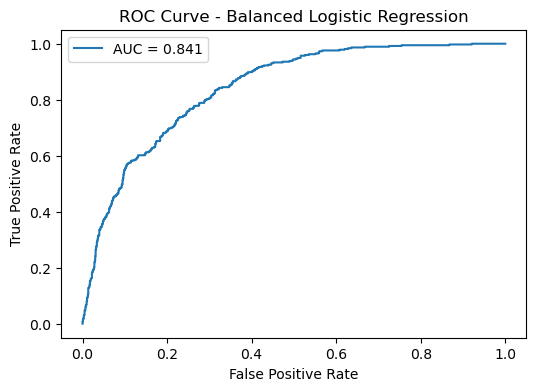

In [124]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,thresholds = roc_curve(y_test, y_prob_lr, pos_label="Yes")

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr, label=f"AUC = {auc_lr:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

In [125]:
y_prob_lr[:10]

array([0.11837823, 0.85164028, 0.14131508, 0.66493518, 0.06142382,
       0.80535184, 0.69950956, 0.2938187 , 0.00883709, 0.65216157])

In [126]:
import numpy as np 
threshold = 0.35

y_pred_custom = np.where(y_prob_lr > threshold, "Yes", "No")

In [127]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[616 419]
 [ 36 338]]
              precision    recall  f1-score   support

          No       0.94      0.60      0.73      1035
         Yes       0.45      0.90      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.81      0.68      0.70      1409



In [128]:
from sklearn.model_selection import cross_val_score

In [129]:
log_model_cv = LogisticRegression(max_iter=1000, class_weight='balanced')

In [130]:
scores = cross_val_score(
    log_model_cv,
    x_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("AUC scores for each fold:", scores)
print("Average AUC:", scores.mean())

AUC scores for each fold: [0.86397896 0.85239042 0.85158661 0.8350702  0.82415994]
Average AUC: 0.8454372253898178


Your Balanced Logistic Regression model generalizes well and maintains consistent predictive performance across multiple folds, with an average ROC-AUC of 0.845.

This indicates strong discrimination ability between churn and non-churn customers.

In [131]:
from sklearn.model_selection import GridSearchCV

In [132]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

In [133]:
print(param_grid)

{'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear'], 'penalty': ['l2']}


In [134]:
grid = GridSearchCV(
    estimator = log_model_cv,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [135]:
grid.fit(x_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [139]:
print("Best Parameters:", grid.best_params_)
print("Best AUC:", grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best AUC: 0.8455924187217747


In [142]:
# from sklearn.pipeline import Pipeline

In [143]:
# import pickle
# pickle.dump(pipe, open("churn_model_pipeline.pkl", "wb"))

In [ ]:
# pipe.fit(x_train, y_train)

In [ ]:
# y_pred_pipe = pipe.predict(x_test)

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report

# print(confusion_matrix(y_test, y_pred_pipe))
# print(classification_report(y_test, y_pred_pipe))

In [ ]:
# import joblib

In [ ]:
# joblib.dump(pipe, "churn_model_pipeline.pkl")

<!-- .pkl = pickle file, a serialized Python object you can load later. -->

In [ ]:
# loaded_model = joblib.load("churn_model_pipeline.pkl")

In [ ]:
# loaded_model.predict(x_test[:5])

In [ ]:
# feature_columns = x_train.columns
# joblib.dump(feature_columns, "feature_columns.pkl")

In [ ]:
# import pickle
# pickle.dump(pipe, open("churn_model_pipeline.pkl", "wb"))

In [73]:
!pip install shap

  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

